# SNN-PC Hybrid Training for Laptop

This notebook prepares and runs training for the `snn_pc_hybrid` project on a local machine.

What it covers:
- local environment checks for Python, PyTorch, and acceleration backends
- repository detection from the notebook location
- optional dependency installation into the active environment
- local output, cache, checkpoint, and log directory setup
- optional training-data preview
- model and trainer initialization
- full curriculum training or a bounded smoke run
- checkpoint inspection, resume flow, and result visualization

Practical notes:
- On macOS, PyTorch `mps` is preferred when available.
- A full curriculum run is long; start with a bounded run first.
- The notebook assumes it lives inside the project repository.

## 1. Set Up Local Environment

This section verifies the local runtime and reports which PyTorch backend is available on your laptop.

In [50]:
import platform
import sys
from pathlib import Path

try:
    import torch
except ImportError:
    torch = None

IN_COLAB = 'google.colab' in sys.modules

print(f'In Colab: {IN_COLAB}')
print(f'Python: {sys.version.split()[0]}')
print(f'Platform: {platform.platform()}')

if torch is None:
    print('Torch is not installed yet. Install dependencies in the next section.')
else:
    print(f'Torch: {torch.__version__}')
    print(f'CUDA available: {torch.cuda.is_available()}')
    has_mps = hasattr(torch.backends, 'mps') and torch.backends.mps.is_available()
    print(f'MPS available: {has_mps}')
    if torch.cuda.is_available():
        print(f'CUDA device: {torch.cuda.get_device_name(0)}')
    elif has_mps:
        print('Using Apple Metal Performance Shaders is possible on this machine.')

In Colab: False
Python: 3.12.10
Platform: macOS-26.2-arm64-arm-64bit
Torch: 2.10.0
CUDA available: False
MPS available: True
Using Apple Metal Performance Shaders is possible on this machine.


In [51]:
import random
import numpy as np
import torch

SEED = 42
INSTALL_REQUIREMENTS = False
AUTO_INSTALL_MISSING_DEPS = True
PREFERRED_INSTALLER = 'pip'  # 'pip' is the safest choice for the active notebook kernel.
RUN_DATA_PREVIEW = False
RUN_FULL_TRAINING = False
START_PHASE = 'bootstrap'
END_PHASE = 'oscar_full' if RUN_FULL_TRAINING else 'bootstrap'
MAX_STEPS = None if RUN_FULL_TRAINING else 50
WIKI_MAX_ARTICLES = None if RUN_FULL_TRAINING else 80
OSCAR_BUFFER_SIZE = 10_000 if RUN_FULL_TRAINING else 512
BATCH_SIZE_HINT = 16
LEARNING_RATE_HINT = 1e-3
RESUME_PHASE = None  # Example: 'bootstrap' or 'wikipedia_long'

print({
    'install_requirements': INSTALL_REQUIREMENTS,
    'auto_install_missing_deps': AUTO_INSTALL_MISSING_DEPS,
    'preferred_installer': PREFERRED_INSTALLER,
    'run_data_preview': RUN_DATA_PREVIEW,
    'run_full_training': RUN_FULL_TRAINING,
    'start_phase': START_PHASE,
    'end_phase': END_PHASE,
    'max_steps': MAX_STEPS,
    'wiki_max_articles': WIKI_MAX_ARTICLES,
    'oscar_buffer_size': OSCAR_BUFFER_SIZE,
    'batch_size_hint': BATCH_SIZE_HINT,
    'learning_rate_hint': LEARNING_RATE_HINT,
    'resume_phase': RESUME_PHASE,
})

{'install_requirements': False, 'auto_install_missing_deps': True, 'preferred_installer': 'pip', 'run_data_preview': False, 'run_full_training': False, 'start_phase': 'bootstrap', 'end_phase': 'bootstrap', 'max_steps': 50, 'wiki_max_articles': 80, 'oscar_buffer_size': 512, 'batch_size_hint': 16, 'learning_rate_hint': 0.001, 'resume_phase': None}


## 2. Locate Repository and Install Dependencies

This section locates the repository from the notebook path heuristics and installs missing dependencies into the currently selected Python environment, falling back to `ensurepip` or `uv` when `pip` is unavailable.

In [52]:
import importlib.util
import os
import shutil
import subprocess
import sys
from pathlib import Path


def find_repo_dir(start: Path, notebook_name: str = 'colab_training.ipynb') -> Path:
    required_markers = {'config.py', 'run_training.py', 'requirements.txt'}
    candidates = []

    for candidate in [start, *start.parents]:
        try:
            names = {path.name for path in candidate.iterdir()}
        except OSError:
            continue

        if not required_markers.issubset(names):
            continue

        score = 0
        if notebook_name in names:
            score += 4
        if '.git' in names:
            score += 2
        if 'uv.lock' in names:
            score += 1
        candidates.append((score, -len(candidate.parts), candidate))

    if not candidates:
        raise FileNotFoundError('Could not locate the snn_pc_hybrid repository root from the notebook location.')

    candidates.sort(reverse=True)
    return candidates[0][2]


def has_module(module_name: str) -> bool:
    return importlib.util.find_spec(module_name) is not None


def run_command(command: list[str], description: str) -> None:
    print(f'Running: {description}')
    subprocess.run(command, check=True)


def ensure_pip_available() -> bool:
    if has_module('pip'):
        return True

    try:
        run_command([sys.executable, '-m', 'ensurepip', '--upgrade'], 'bootstrap pip with ensurepip')
    except (subprocess.CalledProcessError, FileNotFoundError):
        return has_module('pip')

    return has_module('pip')


def install_with_pip(requirement_args: list[str]) -> None:
    if not ensure_pip_available():
        raise RuntimeError('pip is not available in the active Python environment.')

    run_command([sys.executable, '-m', 'pip', 'install', *requirement_args], f'pip install {requirement_args}')


def install_with_uv(requirement_args: list[str]) -> None:
    uv_executable = shutil.which('uv')
    if not uv_executable:
        raise RuntimeError('uv is not installed or not available on PATH.')

    run_command([uv_executable, 'pip', 'install', '--python', sys.executable, *requirement_args], f'uv pip install {requirement_args}')


def install_requirements(requirement_args: list[str]) -> None:
    installer = PREFERRED_INSTALLER.lower().strip()

    if installer == 'uv':
        try:
            install_with_uv(requirement_args)
            return
        except RuntimeError as exc:
            print(f'uv install unavailable: {exc}. Falling back to pip.')

    try:
        install_with_pip(requirement_args)
    except RuntimeError as exc:
        print(f'pip install unavailable: {exc}')
        install_with_uv(requirement_args)


REPO_DIR = find_repo_dir(Path.cwd().resolve())
os.chdir(REPO_DIR)
print(f'Repository directory: {REPO_DIR}')
print(f'Python executable: {sys.executable}')

required_modules = {
    'transformers': 'transformers>=4.38',
    'sentencepiece': 'sentencepiece>=0.1.99',
    'datasets': 'datasets>=2.18',
    'pandas': 'pandas>=2.1',
    'matplotlib': 'matplotlib>=3.8',
    'seaborn': 'seaborn>=0.13',
}
missing_requirements = [requirement for module_name, requirement in required_modules.items() if not has_module(module_name)]
print({'missing_requirements': missing_requirements})

if INSTALL_REQUIREMENTS:
    install_requirements(['--upgrade', 'pip', 'setuptools', 'wheel'])
    install_requirements(['-r', 'requirements.txt'])
    install_requirements(['pandas', 'matplotlib', 'seaborn'])
elif AUTO_INSTALL_MISSING_DEPS and missing_requirements:
    print('Installing missing notebook dependencies into the active kernel environment...')
    install_requirements(missing_requirements)
else:
    print('Dependency installation skipped. Set INSTALL_REQUIREMENTS = True to force a full install.')

post_install_missing = [requirement for module_name, requirement in required_modules.items() if not has_module(module_name)]
if post_install_missing:
    raise ImportError(f'Missing dependencies in the active notebook environment: {post_install_missing}')

print('Notebook dependencies are available in the current Python environment.')

Repository directory: /Users/baptistecaillerie/Documents/Micelaneous/PC-SNN/snn_pc_hybrid
Python executable: /Users/baptistecaillerie/Documents/Micelaneous/PC-SNN/snn_pc_hybrid/.venv/bin/python
{'missing_requirements': []}
Dependency installation skipped. Set INSTALL_REQUIREMENTS = True to force a full install.
Notebook dependencies are available in the current Python environment.


## 3. Configure Paths, Runtime, and Device

This section creates local cache, log, checkpoint, and result directories and selects the best training device available on the laptop.

In [53]:
OUTPUT_ROOT = REPO_DIR / 'notebook_runs'
RESULTS_DIR = OUTPUT_ROOT / 'results'
CHECKPOINT_DIR = OUTPUT_ROOT / 'checkpoints'
LOG_CSV = OUTPUT_ROOT / 'logs' / 'training_log.csv'
HF_HOME = REPO_DIR / 'cache'

for path in [RESULTS_DIR, CHECKPOINT_DIR, LOG_CSV.parent, HF_HOME]:
    path.mkdir(parents=True, exist_ok=True)

os.environ['HF_HOME'] = str(HF_HOME)
os.environ['TRANSFORMERS_CACHE'] = str(HF_HOME / 'transformers')
os.environ['HF_DATASETS_CACHE'] = str(HF_HOME / 'datasets')
os.environ.setdefault('TOKENIZERS_PARALLELISM', 'false')

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

if torch.cuda.is_available():
    device = 'cuda'
elif hasattr(torch.backends, 'mps') and torch.backends.mps.is_available():
    device = 'mps'
else:
    device = 'cpu'

print({
    'device': device,
    'repo_dir': str(REPO_DIR),
    'output_root': str(OUTPUT_ROOT),
    'results_dir': str(RESULTS_DIR),
    'checkpoint_dir': str(CHECKPOINT_DIR),
    'log_csv': str(LOG_CSV),
    'hf_home': str(HF_HOME),
})

{'device': 'mps', 'repo_dir': '/Users/baptistecaillerie/Documents/Micelaneous/PC-SNN/snn_pc_hybrid', 'output_root': '/Users/baptistecaillerie/Documents/Micelaneous/PC-SNN/snn_pc_hybrid/notebook_runs', 'results_dir': '/Users/baptistecaillerie/Documents/Micelaneous/PC-SNN/snn_pc_hybrid/notebook_runs/results', 'checkpoint_dir': '/Users/baptistecaillerie/Documents/Micelaneous/PC-SNN/snn_pc_hybrid/notebook_runs/checkpoints', 'log_csv': '/Users/baptistecaillerie/Documents/Micelaneous/PC-SNN/snn_pc_hybrid/notebook_runs/logs/training_log.csv', 'hf_home': '/Users/baptistecaillerie/Documents/Micelaneous/PC-SNN/snn_pc_hybrid/cache'}


## 4. Load and Prepare Training Data

This optional section previews a small bootstrap subset so you can verify tokenization and batching locally before a long run.

In [54]:
from torch.utils.data import DataLoader, random_split
import importlib

import config as config_module
import run_training as run_training_module
import training.datasets as datasets_module

config_module = importlib.reload(config_module)
run_training_module = importlib.reload(run_training_module)
datasets_module = importlib.reload(datasets_module)

SNNConfig = config_module.SNNConfig
load_tokenizer = run_training_module.load_tokenizer
WikiFrDataset = datasets_module.WikiFrDataset

preview_config = SNNConfig()
preview_config.data_cache_dir = str(HF_HOME)
preview_config.wiki_max_articles = min(WIKI_MAX_ARTICLES or 40, 40)
preview_config.phase_max_tokens['bootstrap'] = 16

tokenizer = load_tokenizer(preview_config)
validation_loader = None

if RUN_DATA_PREVIEW:
    preview_dataset = WikiFrDataset(
        tokenizer=tokenizer,
        max_tokens=preview_config.phase_max_tokens['bootstrap'],
        min_tokens=8,
        length_curriculum=True,
        cache_dir=str(HF_HOME / 'wikipedia'),
        config_name=preview_config.wikipedia_config_name,
        max_articles=preview_config.wiki_max_articles,
    )

    preview_len = len(preview_dataset)
    val_len = max(1, int(0.1 * preview_len))
    train_len = max(1, preview_len - val_len)
    preview_train, preview_val = random_split(
        preview_dataset,
        [train_len, val_len],
        generator=torch.Generator().manual_seed(SEED),
    )

    preview_batch_size = min(BATCH_SIZE_HINT, max(1, len(preview_train)))
    validation_batch_size = min(BATCH_SIZE_HINT, max(1, len(preview_val)))
    preview_loader = DataLoader(preview_train, batch_size=preview_batch_size, shuffle=False, num_workers=0, drop_last=False)
    validation_loader = DataLoader(preview_val, batch_size=validation_batch_size, shuffle=False, num_workers=0, drop_last=False)
    preview_batch = next(iter(preview_loader))
    print({
        'preview_dataset_size': preview_len,
        'train_preview_size': len(preview_train),
        'validation_preview_size': len(preview_val),
        'preview_batch_shape': tuple(preview_batch['input_ids'].shape),
    })
else:
    print('Data preview skipped. Set RUN_DATA_PREVIEW = True to build a small preview dataset.')

  Chargement du tokenizer 'camembert-base'...
  Taille du vocabulaire : 32005
Data preview skipped. Set RUN_DATA_PREVIEW = True to build a small preview dataset.


## 5. Build Training Configuration

This cell creates the runtime configuration that will be used by the project trainer.

In [55]:
train_config = SNNConfig()
train_config.data_cache_dir = str(HF_HOME)
train_config.checkpoint_dir = str(CHECKPOINT_DIR)
train_config.log_csv_path = str(LOG_CSV)
train_config.wiki_max_articles = WIKI_MAX_ARTICLES
train_config.oscar_buffer_size = OSCAR_BUFFER_SIZE
train_config.max_steps_override = MAX_STEPS
train_config.device = torch.device(device)

training_plan = {
    'start_phase': START_PHASE,
    'end_phase': END_PHASE,
    'max_steps_override': train_config.max_steps_override,
    'wiki_max_articles': train_config.wiki_max_articles,
    'oscar_buffer_size': train_config.oscar_buffer_size,
    'batch_size_hint': BATCH_SIZE_HINT,
    'learning_rate_hint': LEARNING_RATE_HINT,
    'checkpoint_dir': train_config.checkpoint_dir,
    'log_csv_path': train_config.log_csv_path,
    'device': str(train_config.device),
}
training_plan

{'start_phase': 'bootstrap',
 'end_phase': 'bootstrap',
 'max_steps_override': 50,
 'wiki_max_articles': 80,
 'oscar_buffer_size': 512,
 'batch_size_hint': 16,
 'learning_rate_hint': 0.001,
 'checkpoint_dir': '/Users/baptistecaillerie/Documents/Micelaneous/PC-SNN/snn_pc_hybrid/notebook_runs/checkpoints',
 'log_csv_path': '/Users/baptistecaillerie/Documents/Micelaneous/PC-SNN/snn_pc_hybrid/notebook_runs/logs/training_log.csv',
 'device': 'mps'}

## 6. Initialize Model, Loss, and Optimizer

This section instantiates the project modules and creates a trainer object. The optimizer is managed by the curriculum trainer per phase.

In [56]:
import importlib

import core.neuron as neuron_module
import modules.arcuate as arcuate_module
import modules.broca as broca_module
import modules.wernicke as wernicke_module
import run_training as run_training_module
import training.loss as loss_module
import training.trainer as trainer_module

neuron_module = importlib.reload(neuron_module)
wernicke_module = importlib.reload(wernicke_module)
broca_module = importlib.reload(broca_module)
arcuate_module = importlib.reload(arcuate_module)
run_training_module = importlib.reload(run_training_module)
loss_module = importlib.reload(loss_module)
trainer_module = importlib.reload(trainer_module)

build_model = run_training_module.build_model
FreeEnergyLoss = loss_module.FreeEnergyLoss
CurriculumTrainer = trainer_module.CurriculumTrainer

wernicke, broca, arcuate = build_model(train_config, tokenizer.vocab_size)
loss_fn = FreeEnergyLoss()
trainer = CurriculumTrainer(
    wernicke=wernicke,
    broca=broca,
    arcuate=arcuate,
    tokenizer=tokenizer,
    config=train_config,
 )

print('Model initialized on:', train_config.device)
print('Checkpoint directory:', train_config.checkpoint_dir)
print('Log CSV:', train_config.log_csv_path)

  Paramètres totaux : 12,421,317
Model initialized on: mps
Checkpoint directory: /Users/baptistecaillerie/Documents/Micelaneous/PC-SNN/snn_pc_hybrid/notebook_runs/checkpoints
Log CSV: /Users/baptistecaillerie/Documents/Micelaneous/PC-SNN/snn_pc_hybrid/notebook_runs/logs/training_log.csv


## 7. Run Training Loop

The project already provides a full curriculum trainer. This cell launches it from the selected start phase to the selected end phase.

In [57]:
import time

results = None
train_started_at = time.time()

print(f'Starting training: {START_PHASE} -> {END_PHASE}')
results = trainer.run(start_phase=START_PHASE, end_phase=END_PHASE)
print('Training finished in seconds:', round(time.time() - train_started_at, 1))
results

Starting training: bootstrap -> bootstrap

  PHASE : BOOTSTRAP
  Seuils : {'F_max': 2.0, 'r_min': 0.5, 'steps': 1000}
  Max tokens : 16
  Wernicke gelé : False
  Broca gelé    : True
  Arcuate gelé  : True
Config Wikipedia demandee '20231101.fr' indisponible; utilisation de '20220301.fr'
Chargement Wikipedia FR (config=20220301.fr, split=train, cache=/Users/baptistecaillerie/Documents/Micelaneous/PC-SNN/snn_pc_hybrid/cache/wikipedia, streaming=True)...


Using the latest cached version of the dataset since wikipedia couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration '20220301.fr' at /Users/baptistecaillerie/Documents/Micelaneous/PC-SNN/snn_pc_hybrid/cache/wikipedia/wikipedia/20220301.fr/2.0.0/d41137e149b2ea90eead07e7e3f805119a8c22dd1d5b61651af8e3e3ee736001 (last modified on Sun Mar  8 19:45:57 2026).
Token indices sequence length is longer than the specified maximum sequence length for this model (1461 > 512). Running this sequence through the model will result in indexing errors


Chunking des articles (max_tokens=16, min_tokens=8)...
  → 29968 chunks produits


bootstrap: 100%|██████████| 50/50 [00:09<00:00,  5.17step/s, F=0.001, r=0.990, lr=1.00e-03]



  Phase 'bootstrap' terminée : 50 steps | F=0.0216 | r=0.9895
  ✓ Checkpoint sauvegardé : /Users/baptistecaillerie/Documents/Micelaneous/PC-SNN/snn_pc_hybrid/notebook_runs/checkpoints/bootstrap.pt
Training finished in seconds: 12.3


{'bootstrap': {'steps': 50,
  'F_final': 0.021570101380348206,
  'r_final': 0.9895316958427429}}

## 8. Evaluate on Validation Data

If you enabled the preview dataset, this section runs a lightweight held-out sanity check after training. Otherwise it skips cleanly.

In [58]:
from core.oscillator import OscillatoryClock

if validation_loader is None:
    print('Validation preview is unavailable. Set RUN_DATA_PREVIEW = True and rerun the preview cells if you want a held-out sanity check.')
else:
    validation_metrics = []
    validation_clock = OscillatoryClock(train_config)
    wernicke.eval()

    with torch.no_grad():
        for batch in validation_loader:
            input_ids = batch['input_ids'].to(train_config.device).long()
            attention_mask = batch['attention_mask'].to(train_config.device)
            x_input = trainer._token_ids_to_bow(input_ids, attention_mask)
            mu_prior = torch.zeros(x_input.shape[0], train_config.dim_wernicke, device=train_config.device)
            out_w = wernicke(x_input=x_input, mu_prior=mu_prior, clock=validation_clock)
            mean_free_energy = 0.5 * (out_w['epsilon'] ** 2).sum(dim=-1).mean().item()
            validation_metrics.append(mean_free_energy)

    wernicke.train()
    mean_validation_free_energy = float(np.mean(validation_metrics)) if validation_metrics else float('nan')
    print({'mean_validation_free_energy': mean_validation_free_energy, 'n_validation_batches': len(validation_metrics)})

Validation preview is unavailable. Set RUN_DATA_PREVIEW = True and rerun the preview cells if you want a held-out sanity check.


## 9. Save and Resume Checkpoints

Checkpoints are written automatically by phase. Use the next cells to inspect available checkpoints and resume from one of them.

In [59]:
available_checkpoints = sorted(CHECKPOINT_DIR.glob('*.pt'))
[str(path) for path in available_checkpoints]

['/Users/baptistecaillerie/Documents/Micelaneous/PC-SNN/snn_pc_hybrid/notebook_runs/checkpoints/bootstrap.pt']

In [60]:
RESUME_PHASE = None  # Example: 'bootstrap' or 'wikipedia_long'

if RESUME_PHASE:
    trainer.load_checkpoint(RESUME_PHASE)
    print(f'Resumed model state from phase: {RESUME_PHASE}')
else:
    print('No checkpoint loaded. Set RESUME_PHASE to resume training.')

No checkpoint loaded. Set RESUME_PHASE to resume training.


## 10. Run Inference and Visualize Predictions

This section loads a sample text, runs a simple Wernicke -> Arcuate -> Broca pass, previews top token predictions, and then displays logs and generated PNG outputs.

In [61]:
sample_text = 'Le chat mange la souris.'
encoded = tokenizer(sample_text, return_tensors='pt', truncation=True, padding=False)
input_ids = encoded['input_ids'].to(train_config.device)
attention_mask = encoded['attention_mask'].to(train_config.device)

wernicke.reset_state()
broca.reset_state()
arcuate.reset_state()

with torch.no_grad():
    x_input = trainer._token_ids_to_bow(input_ids, attention_mask)
    inference_clock = OscillatoryClock(train_config)
    mu_prior = torch.zeros(x_input.shape[0], train_config.dim_wernicke, device=train_config.device)
    out_w = wernicke(x_input=x_input, mu_prior=mu_prior, clock=inference_clock)
    msg_w2b, _ = arcuate.transmit(message=out_w['prediction'], direction='W2B', visit_history=['W'])
    context = torch.zeros(x_input.shape[0], train_config.dim_broca, device=train_config.device)
    out_b = broca(mu_wernicke=msg_w2b, x_context=context, clock=inference_clock)
    top_ids = out_b['logits'][0].topk(10).indices.tolist()
    top_tokens = tokenizer.convert_ids_to_tokens(top_ids)

{'sample_text': sample_text, 'top_token_predictions': top_tokens}

{'sample_text': 'Le chat mange la souris.',
 'top_token_predictions': ['▁rencontres',
  '▁Châ',
  '▁étendue',
  '▁Référence',
  '▁imprimé',
  '▁flood',
  '▁retrouva',
  '▁plasticien',
  '▁recevable',
  '▁pouvais']}

In [62]:
import pandas as pd

if LOG_CSV.exists():
    log_df = pd.read_csv(LOG_CSV)
    display(log_df.tail(20))
else:
    print(f'Log file not found: {LOG_CSV}')

,phase,step,F_W,F_B,F_total,r_W,r_B,sync_loss,lr,elapsed_s
30,bootstrap,30,0.003193,0.0,0.003193,0.989532,0.989532,0.0,0.001,6.5
31,bootstrap,31,0.002748,0.0,0.002748,0.989532,0.989532,0.0,0.001,6.7
32,bootstrap,32,0.002561,0.0,0.002561,0.989532,0.989532,0.0,0.001,6.8
33,bootstrap,33,0.002245,0.0,0.002245,0.989532,0.989532,0.0,0.001,7.0
34,bootstrap,34,0.002271,0.0,0.002271,0.989532,0.989532,0.0,0.001,7.1
35,bootstrap,35,0.001757,0.0,0.001757,0.989532,0.989532,0.0,0.001,7.3
36,bootstrap,36,0.001721,0.0,0.001721,0.989532,0.989532,0.0,0.001,7.4
37,bootstrap,37,0.001834,0.0,0.001834,0.989532,0.989532,0.0,0.001,7.6
38,bootstrap,38,0.001707,0.0,0.001707,0.989532,0.989532,0.0,0.001,7.8
39,bootstrap,39,0.001555,0.0,0.001555,0.989532,0.989532,0.0,0.001,8.0


Found 0 PNG files under /Users/baptistecaillerie/Documents/Micelaneous/PC-SNN/snn_pc_hybrid/notebook_runs/results


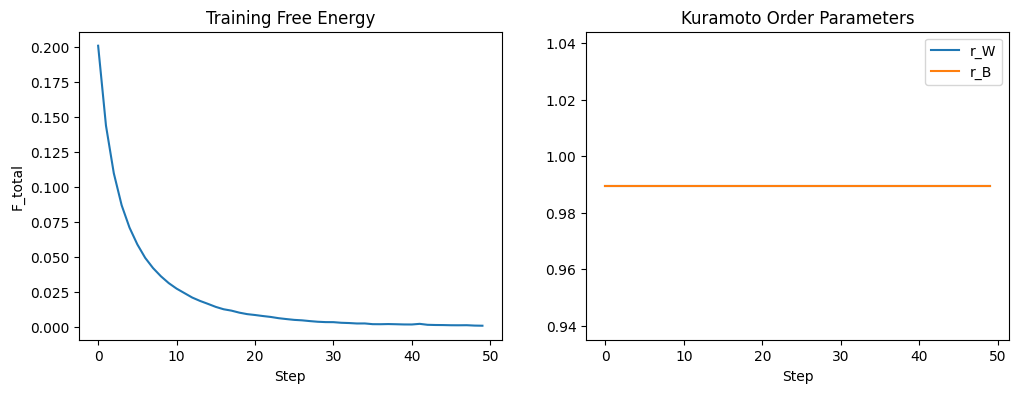

In [63]:
import math
import matplotlib.pyplot as plt
from IPython.display import Image, display

png_files = sorted(RESULTS_DIR.rglob('*.png'))
print(f'Found {len(png_files)} PNG files under {RESULTS_DIR}')
for png_path in png_files:
    print(png_path)
    display(Image(filename=str(png_path)))

if LOG_CSV.exists():
    log_df = pd.read_csv(LOG_CSV)
    if not log_df.empty:
        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        axes[0].plot(log_df['step'], log_df['F_total'])
        axes[0].set_title('Training Free Energy')
        axes[0].set_xlabel('Step')
        axes[0].set_ylabel('F_total')
        axes[1].plot(log_df['step'], log_df['r_W'], label='r_W')
        axes[1].plot(log_df['step'], log_df['r_B'], label='r_B')
        axes[1].set_title('Kuramoto Order Parameters')
        axes[1].set_xlabel('Step')
        axes[1].legend()
        plt.show()